In [35]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ["HUGGINGFACE_API_KEY"] = os.getenv("HUGGINGFACE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

#SET EMBEDDINGS
embeddings = HuggingFaceEmbeddings()


In [36]:
#DOCS TO INDEX
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/"
]

#LOAD
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

#SPLIT
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=50
)

docs_splits = text_splitter.split_documents(docs_list)

#ADD TO VECTORSORE DB

vectorstore = FAISS.from_documents(
    documents=docs_splits,
    embedding=embeddings
)

#Retriver
retriever = vectorstore.as_retriever()

In [37]:
#ROUTER
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

#DATA MODEL
class RouteQuery(BaseModel):
    """Routes a user query to the most relevant documents"""

    datasource : Literal['vectorstore','web_search'] = Field(description="Given a user question choose to route it to web search or vector store")

## LLM with Function Call
llm = ChatGroq(model="qwen/qwen3-32b")

structured_llm_router = llm.with_structured_output(RouteQuery)


In [38]:
#PROMPT
system = """You are an expert at routing the user question to a vectorstore or websearch. 
            The vectorstore contains documents related to agents, prompt engineering, and adversial attacks. Use the vector store for questions on these topucs, otherwise choose web search
"""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human",'{question}')
    ]
)

question_route = route_prompt | structured_llm_router

In [39]:
print(question_route.invoke({'question':"Who won the cricket world cup 2026?"}))

datasource='web_search'


In [40]:
print(question_route.invoke({'question':"What are the types of agent memory?"}))

datasource='vectorstore'


In [41]:
##Retrival Grader
#Data Model
class GradeDocuments(BaseModel):
    "Binary Score for relevance check on retrieved documents"

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

##LLM with Function Call
llm = ChatGroq(model="qwen/qwen3-32b")

structured_llm_grader = llm.with_structured_output(GradeDocuments)

#Prompt
system = """You are a grader assessing relevance of a retrieved documents to a user question.\n
            if the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.\n
            if does not need to be stringent test. the goal is to filter out errornous retrievals.\n Give a binary score 'yes' or 'no' to indicate whether the documents retrieved is relevant to the question."""

grader_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',system),
        ('human',"Retrieved Documents: \n\n {documents}\n\n User Question: \n{question}")
    ]
)

retrieval_grader = grader_prompt | structured_llm_grader

question = 'Agent Memory'

docs = retriever.invoke(question)
docs_text = docs[1].page_content

print(retrieval_grader.invoke({
    "question":question,
    "documents":docs_text
}))

binary_score='yes'


In [42]:
#Generate
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

#Prompt
prompt = hub.pull('rlm/rag-prompt')

#LLM
llm = ChatGroq(model="qwen/qwen3-32b")

#Post Processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

#chain
rag_chain = prompt | llm | StrOutputParser()

#Run
generation = rag_chain.invoke({
    'context':docs,
    'question':question
})

print(generation)


<think>
Okay, the user is asking about "Agent Memory" in the context of LLM-powered autonomous agents. Let me check the provided documents to find relevant information.

Looking at the first document, under the "Memory" section, there's a mention of short-term and long-term memory. Short-term is about in-context learning, like prompt engineering, while long-term uses external vector stores for infinite information retention. The other documents also discuss similar points, and one even talks about challenges like finite context length affecting memory. 

Another document mentions retrieval models that use recency, relevance, and importance to surface context. There's also a reflection mechanism that synthesizes memories into higher-level inferences. So, putting this together, agent memory has two types: short-term (in-context) and long-term (external storage). Challenges include context length limitations, but external tools help with retrieval. Reflection helps in learning from past a

In [43]:
##HALLUCINATION GRADER

#Data Model
class hallucination_grader(BaseModel):
    """Binary Score for hallucinations present in the generative answer"""

    binary_score: str = Field(
        description="Answer is generated in the fact, 'yes' or 'no'"
    )

#LLM with function call
llm = ChatGroq(model="qwen/qwen3-32b")

structured_llm_hallucination_grader = llm.with_structured_output(hallucination_grader)

#Prompt
system = """You are a hallucination grader assessing whether the generation is grounded-in or supported by a set of retrieved facts.\n
            Give a binary score 'yes' or 'no' means that answer is grounded in or supported by the set of facts"""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',system),
        ('human','Set of facts:\n\n {documents} \n\n LLM Generation: {generation}')
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_hallucination_grader

hallucination_grader.invoke({'documents':docs,'generation':generation})

hallucination_grader(binary_score='yes')

In [44]:
## ANSWER GRADER

#DATA MODEL
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question"""

    binary_score: str = Field(description="Answer addresses the question, 'yes' or 'no'")


#LLM with function call
llm = ChatGroq(model="qwen/qwen3-32b")

strucutred_llm_answer_grader = llm.with_structured_output(GradeAnswer)

In [45]:
#PROMPT
system = """You are a answer grader assessing whether an asnwer addresses the question correctly or not.\n
            Give a binary score 'yes' or 'no'.\n 'yes' means that the answer resolves the question."""

answer_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',system),
        ('human','User Question:\n {question} \n\n LLM Generated Answer:\n {generation}')
    ]
)

answer_grader = answer_prompt | strucutred_llm_answer_grader

answer_grader.invoke({
    'question':question,
    'generation':generation
})

GradeAnswer(binary_score='yes')

In [46]:
##Question REWRITER
#LLM
llm = ChatGroq(model="qwen/qwen3-32b")

#PROMT
system = """You are an expert question re-writer that converts an input question to a bteer version that is optmised for vectorstore retrieval.\n
            Look at the input and try to reason about the underlying semantic intent/meaning"""

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',system),
        ('human','Here is the initial question:\n {question} \n formulate an improved question:\n')
    ]
)

question_rewriter = rewrite_prompt | llm | StrOutputParser()

question_rewriter.invoke({'question':question})

'<think>\nOkay, let\'s see. The user wants me to improve the question "Agent Memory" into something better for vectorstore retrieval. First, I need to understand what "Agent Memory" refers to. Maybe they\'re talking about the memory systems in AI agents, like how agents store and retrieve information.\n\nThe original question is pretty vague. It\'s just two words. To make it better, I should expand it to capture the intent. What exactly do they want to know about agent memory? Are they looking for methods to implement it, best practices, challenges, or something else?\n\nThe user mentioned optimizing for vectorstore retrieval. So the improved question should include terms related to vector databases. Terms like "implementing," "optimize," "store," "retrieve," "vector database," "machine learning models," "AI agents" come to mind. Also, maybe specify the purpose, like improving efficiency or enhancing retrieval accuracy.\n\nI should ask how to design or implement an agent memory system 

In [47]:
## SEARCH

from langchain_community.tools import TavilySearchResults
from typing import List
from typing_extensions import TypedDict

web_search_tool = TavilySearchResults(k=3)

class GraphState(TypedDict):
    """Represents the state of the graph.
    
    ATTRIBUTES:
        question: question input by the user.
        generation: LLM response.
        documents: List of documents fetched from the vector store"""
    
    question: str
    generation: str
    documents: List[str]


from langchain_classic.schema import Document

def retrieve(state):
    """Retrieve Documents from vectorstore for the provided question
    
    ARGS:
        state(dict): the current state of the graph
        
    RETURNS:
        State(Dict): New Key added to the state, documents, that contains retrieved documents."""
    
    print("---RETRIEVING DOCUMENTS---")
    question = state['question']
    retrieved_docs = retriever.invoke(question)

    return {
        "question":question,
        "documents":retrieved_docs
    }

def generate(state):
    """Generate response based on user question
    
    ATTRIBUTES:
        State(dict): the current state of the graph
        
    RETURNS:
        State(Dict): New Key is added to the state, generation, that contains LLM reponse."""
    print("---GENERATING LLM RESPONSE---")
    question = state['question']
    retrieved_docs = state['documents']
    generation = rag_chain.invoke({
        'question':question,
        'context':retrieved_docs
    })

    return {
        'question':question,
        'documents':retrieved_docs,
        'generattion':generation
    }

def grade_documents(state):
    """Determines whether retrieved documents are relevant to the question.
    
    Args: 
    - State(dict): the current state of the graph.
    
    Return:
    - State(dict): Update the documents key with only filtered relevant docments"""

    print("---CHECKING RELEVANCE OF RETRIEVED DOCUMENTS TO QUESTION---")
    question = state['question']
    documents = state['documents']
    
    #Score Each Document
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke({
            'question':question,
            'documents':d.page_content
        })

        grade = score.binary_score
        if grade == 'yes':
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)

        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue

    return {
        "question":question,
        "documents":filtered_docs
    }

def transform_query(state):
    """Transforms the user question into more optimised version to provide a better answer.
    
    Args:
        - state(dict): the current state of the graph
        
    Returns:
        - state(dict): Update question key with a rephrased question"""
    
    question = state['question']
    print("---TRANSFORMING QUERY---")
    documents = state['documents']

    better_question = question_rewriter.invoke({
        'question':question
    })

    return {
        'question':better_question,
        'documents': documents
    }

def web_search(state):
    """Web search based on the rephrased question
    
    ARGS:
        - state(dict): The cuurent state of the graph
        
    RETURNS:
        - state(dict): update documents key with appended web results."""
    
    print("---WEB RESULTS---")
    question = state['question']

    docs = web_search_tool.invoke({'query':question})
    web_results = "\n".join([d['content'] for d in docs])
    web_results = Document(page_content=web_results)

    return {
        'documents':web_results,
        'question':question
    }

In [48]:
##EDGES

def route_question(state):
    """Routes question to web search or RAG
    
    ARGS:
        state(dict): the current state of the graph
        
    RETURNS:
        state(dict): Next node to call"""
    
    print("---ROUTING QUESTION---")
    question = state['question']

    source = question_route.invoke({'question':question})
    if source.datasource == 'web_search':
        print("---ROUTING QUERY TO WEB SEARCH---")
        return 'web_search'
    elif source.datasource == "vectorstore":
        print("---ROUTING QUESTION TO RAG---")
        return "vectorstore"
    
def decide_to_generate(state):
    """Determines whether to generate the answwr to need to regenerate the question.
    
    Args:
        state(dict): the current state of the graph
        
    Output:
        str: binary decision for next node to call"""
    
    print("---ASSESS GRADED DOCUMENTS---")
    question = state['question']
    filtered_documents = state['documents']
    if not filtered_documents:
        # All documnents have been filtered out while checking relevance
        # we will regenerate the query

        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO THE QUESTION - TRANSFORM QUERY---")
        return 'transform_query'
    else:
        print("---DECISION: RELEVANT DOCUMENTS FOUND TO GENERATE ANSWER---")
        return "generate"
    
def grade_generation_documents_and_questions(state):
    """Determines whether the generation is grounded in the document and answers question.
    
    ARGS:
        state(dict): The current state of the graph
        
    RETURNS:
        str: Decision for next node to call"""
    
    print("---CHECK HALLUCINATIONS---")
    documents = state['documents']
    generation = state['generation']

    score = hallucination_grader.invoke({
        'generation':generation,
        'documents':documents
    })

    grade = score.binary_score

    #Check Hallucinations
    if grade == 'yes':
        print("---DECISION: GENERATION IS GROUNDED TO DOCUMENTS")
        #checking question answering
        print("---GRADE GENERATION VS QUESTION---")
        score = answer_grader.invoke({
            "question":question,
            "generation":generation
        })
        grade = score.binary_score
        if grade == 'yes':
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return 'useful'
        else:
            print("DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not_useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return 'not_supported'

    


In [49]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

#DEFINE NODES
workflow.add_node('retrieve',retrieve)
workflow.add_node('web_search', web_search)
workflow.add_node('grade_documents', grade_documents)
workflow.add_node('generate',generate)
workflow.add_node('transform_query', transform_query)

In [50]:
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'web_search':'web_search',
        'vectorstore':'retrieve'
    }
)
workflow.add_edge('web_search','generate')
workflow.add_edge('retrieve', 'grade_documents')
workflow.add_conditional_edges(
    'grade_documents',
    decide_to_generate,
    {
        'transform_query':'transform_query',
        'generate':'generate'
    }
)
workflow.add_edge('transform_query','retrieve')
workflow.add_conditional_edges(
    'generate',
    grade_generation_documents_and_questions,
    {
        'not_supported':'generate',
        'useful':END,
        'not_useful':'transform_query'
    }
)

#COMPILE
app = workflow.compile()

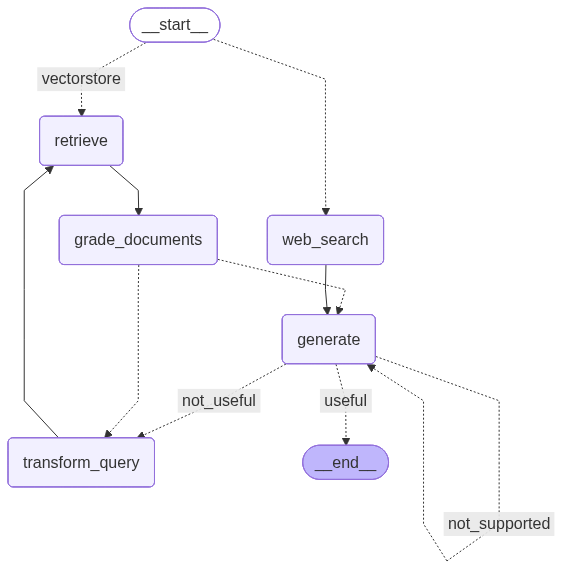

In [51]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [52]:
app.invoke({'question':"What is Machine Learning?"})

---ROUTING QUESTION---
---ROUTING QUERY TO WEB SEARCH---
---WEB RESULTS---
---GENERATING LLM RESPONSE---
---CHECK HALLUCINATIONS---


KeyError: 'generation'